In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras import optimizers
from keras.layers import LSTM
from keras.layers import Dense, Reshape
from keras.models import Sequential
import math
import sys
sys.path.insert(0, '..')
from lstm import AVERT_LSTM

processed_dpath = '../processed_data/'

### Basic usage example

In [ ]:
# usage

# read in dataInterpolated.csv
df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)

# define variables to input into LSTM
input_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 
predict_vars = ['Eruption_Activity']

# define and fit the model
lstm = AVERT_LSTM(df, input_vars=input_vars)
lstm.CreateModel(n_past=3, n_future=2, n_epochs=2)
lstm.Fit()

# predict using the model
lstm.Predict()
lstm.PlotData([lstm.df, lstm.df_pred])

# original DataFrame for y data
dataOrig = lstm.df_y

# predicted DataFrame
dataPred = lstm.df_yhat

### Alex sandbox

Performing Training...
Epoch 1/150


/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 - 2s - 576ms/step - loss: 0.0576 - val_loss: 0.0474
Epoch 2/150
3/3 - 1s - 242ms/step - loss: 0.0480 - val_loss: 0.0517
Epoch 3/150
3/3 - 1s - 244ms/step - loss: 0.0357 - val_loss: 0.0468
Epoch 4/150
3/3 - 1s - 243ms/step - loss: 0.0291 - val_loss: 0.0420
Epoch 5/150
3/3 - 1s - 234ms/step - loss: 0.0259 - val_loss: 0.0433
Epoch 6/150
3/3 - 1s - 238ms/step - loss: 0.0281 - val_loss: 0.0405
Epoch 7/150
3/3 - 1s - 233ms/step - loss: 0.0200 - val_loss: 0.0349
Epoch 8/150
3/3 - 1s - 231ms/step - loss: 0.0192 - val_loss: 0.0330
Epoch 9/150
3/3 - 1s - 227ms/step - loss: 0.0169 - val_loss: 0.0302
Epoch 10/150
3/3 - 1s - 231ms/step - loss: 0.0150 - val_loss: 0.0310
Epoch 11/150
3/3 - 1s - 245ms/step - loss: 0.0147 - val_loss: 0.0304
Epoch 12/150
3/3 - 1s - 217ms/step - loss: 0.0138 - val_loss: 0.0300
Epoch 13/150
3/3 - 1s - 212ms/step - loss: 0.0135 - val_loss: 0.0281
Epoch 14/150
3/3 - 1s - 211ms/step - loss: 0.0121 - val_loss: 0.0278
Epoch 15/150
3/3 - 1s - 211ms/step - loss: 0.0119 - val

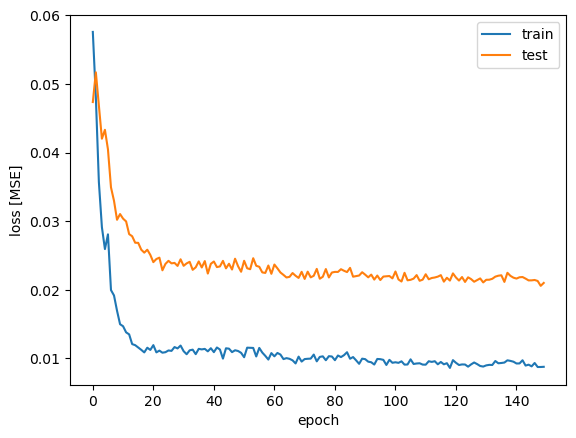

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Test RMSE: 0.021


/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:204: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=10)
/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:204: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


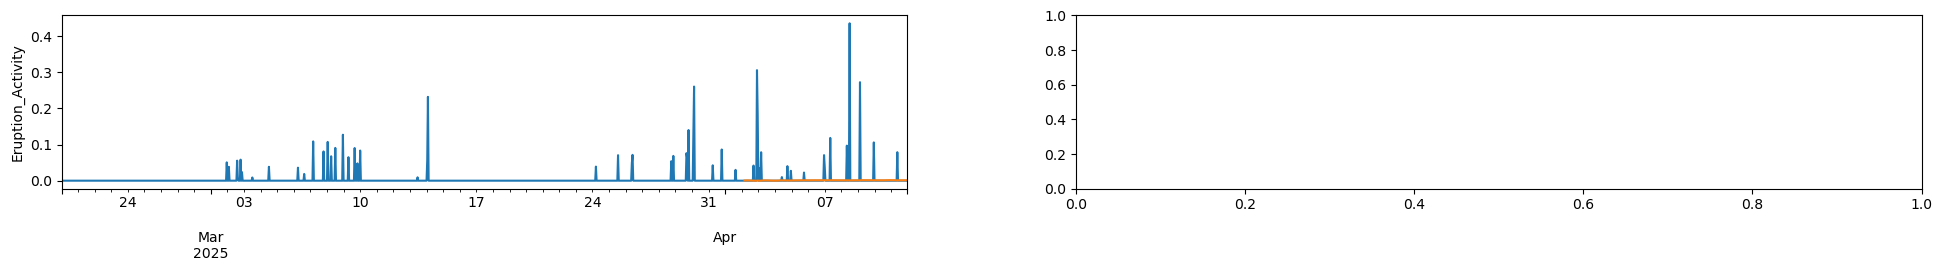

In [9]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

#df['log_Eruption_Activity'] = np.log(df['Eruption_Activity'])
df['log_VPCC_RSAM'] = np.log(df['VPCC_RSAM'])
df['log_VPPC_RSAM'] = np.log(df['VPPC_RSAM'])
df['log_VPNC_RSAM'] = np.log(df['VPNC_RSAM'])
df['log_VPRS_RSAM'] = np.log(df['VPRS_RSAM'])

# cut the range and resample to one data point per hour
df = df["2025-02-20":"2025-04-11"].resample('h').mean()
input_vars = ['Eruption_Activity', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']
predict_vars = ['Eruption_Activity']

# define model and plot data
lstm = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)
lstm.CreateModel(n_past=30, n_future=15, n_epochs=150)
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
lstm.PlotData([lstm.df_y, lstm.df_yhat], log_vars=[])

Performing Training...
Epoch 1/300


/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 1s - 693ms/step - accuracy: 0.8749 - binary_accuracy: 0.8749 - loss: 0.6730 - val_accuracy: 0.9323 - val_binary_accuracy: 0.9323 - val_loss: 0.6267
Epoch 2/300
2/2 - 0s - 42ms/step - accuracy: 0.8799 - binary_accuracy: 0.8799 - loss: 0.6208 - val_accuracy: 0.9323 - val_binary_accuracy: 0.9323 - val_loss: 0.5743
Epoch 3/300
2/2 - 0s - 40ms/step - accuracy: 0.8799 - binary_accuracy: 0.8799 - loss: 0.5715 - val_accuracy: 0.9323 - val_binary_accuracy: 0.9323 - val_loss: 0.5200
Epoch 4/300
2/2 - 0s - 39ms/step - accuracy: 0.8799 - binary_accuracy: 0.8799 - loss: 0.5231 - val_accuracy: 0.9323 - val_binary_accuracy: 0.9323 - val_loss: 0.4634
Epoch 5/300
2/2 - 0s - 41ms/step - accuracy: 0.8799 - binary_accuracy: 0.8799 - loss: 0.4767 - val_accuracy: 0.9323 - val_binary_accuracy: 0.9323 - val_loss: 0.4072
Epoch 6/300
2/2 - 0s - 40ms/step - accuracy: 0.8799 - binary_accuracy: 0.8799 - loss: 0.4363 - val_accuracy: 0.9323 - val_binary_accuracy: 0.9323 - val_loss: 0.3578
Epoch 7/300
2/2 - 0s 

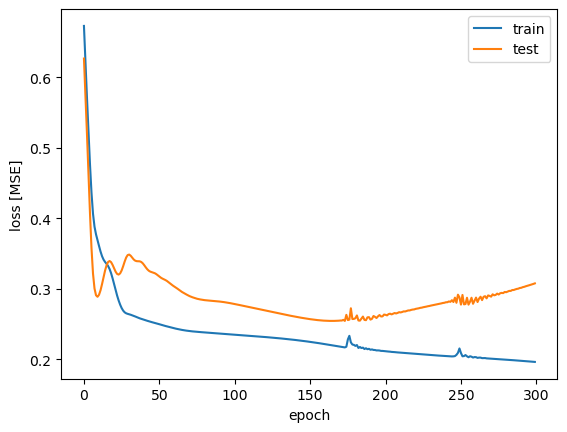

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Test RMSE: 0.070


/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:218: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=10)
/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:218: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


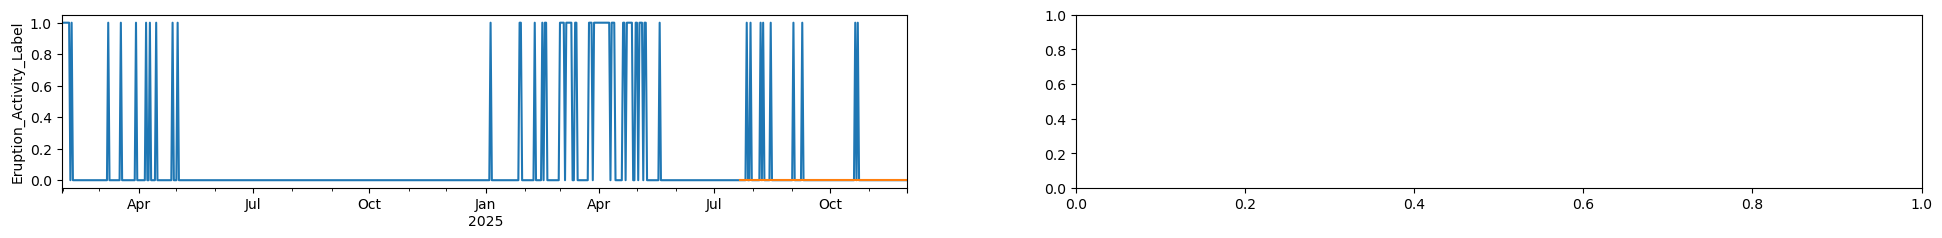

In [8]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

#df['log_Eruption_Activity'] = np.log(df['Eruption_Activity'])
df['log_VPCC_RSAM'] = np.log(df['VPCC_RSAM'])
df['log_VPPC_RSAM'] = np.log(df['VPPC_RSAM'])
df['log_VPNC_RSAM'] = np.log(df['VPNC_RSAM'])
df['log_VPRS_RSAM'] = np.log(df['VPRS_RSAM'])

# cut the range and resample to one data point per hour
df = df.resample('d').mean()
df['Eruption_Activity_Label'] = (df['Eruption_Activity'] > 0).astype(int)
input_vars = ['Eruption_Activity_Label', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']
predict_vars = ['Eruption_Activity_Label']

# define model and plot data
lstm = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)
lstm.CreateModel(n_past=3, n_future=3, n_epochs=300, n_divide=0.8, n_neurons=400, learning_rate=0.001, momentum=0.4, opt ='adam', activation='tanh', task_type='binary')
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
lstm.PlotData([lstm.df_y, (lstm2.df_yhat > 0).astype(int)], log_vars=[])

In [2]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

#df['log_Eruption_Activity'] = np.log(df['Eruption_Activity'])
df['log_VPCC_RSAM'] = np.log(df['VPCC_RSAM'])
df['log_VPPC_RSAM'] = np.log(df['VPPC_RSAM'])
df['log_VPNC_RSAM'] = np.log(df['VPNC_RSAM'])
df['log_VPRS_RSAM'] = np.log(df['VPRS_RSAM'])

# cut the range and resample to one data point per hour
df = df.resample('d').mean()
df['Eruption_Activity_Label'] = (df['Eruption_Activity'] > 0).astype(int)
input_vars = ['Eruption_Activity_Label', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']
predict_vars = ['Eruption_Activity_Label']

# define model and plot data
lstm2 = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)
lstm2.CreateModel(n_past=3, n_future=3, n_epochs=300, n_divide=0.8, n_neurons=800, learning_rate=0.001, momentum=0.4, opt ='adam', activation='tanh')
#lstm.model.summary()
lstm2.Fit()
lstm2.Predict()
lstm2.PlotData([lstm2.df_y, (lstm2.df_yhat > 0).astype(int)], log_vars=[])

KeyboardInterrupt: 